# Student Performance Data Analysis

Exploratory data analysis using Python (Pandas, NumPy, Matplotlib, Seaborn).

Goals:
- Explore correlations between study habits and grades
- Visualize dataset patterns
- Build a simple predictive model

## Dataset
We use the **Student Performance** dataset from the **UCI Machine Learning Repository**.


In [8]:
# If needed, uncomment the next line the first time you run the notebook
# !pip install ucimlrepo pandas numpy matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression


## 1. Load the dataset

In [9]:
student_performance = fetch_ucirepo(id=320)

X = student_performance.data.features.copy()
y = student_performance.data.targets.copy()

df = pd.concat([X, y], axis=1)

print("Shape:", df.shape)
display(df.head())


Shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


## 2. Quick overview

In [10]:
print("Column types:")
display(df.dtypes)

print("\nMissing values per column:")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("\nNumeric summary:")
display(df.describe())


Column types:


school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object


Missing values per column:


school     0
sex        0
age        0
address    0
famsize    0
Pstatus    0
Medu       0
Fedu       0
Mjob       0
Fjob       0
dtype: int64


Numeric summary:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


## 3. Focus on useful variables

The final grade is **G3**.  
Some variables are especially interesting for a first analysis:
- `studytime`
- `failures`
- `absences`
- `internet`
- `higher`
- `G1`, `G2` (earlier grades)


In [11]:
selected_cols = ["studytime", "failures", "absences", "internet", "higher", "G1", "G2", "G3"]
display(df[selected_cols].head())


,studytime,failures,absences,internet,higher,G1,G2,G3
0,2,0,4,no,yes,0,11,11
1,2,0,2,yes,yes,9,11,11
2,2,0,6,yes,yes,12,13,12
3,3,0,0,yes,yes,14,14,14
4,2,0,0,no,yes,11,13,13


## 4. Correlation analysis

G3            1.000000
G2            0.918548
G1            0.826387
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316
Name: G3, dtype: float64

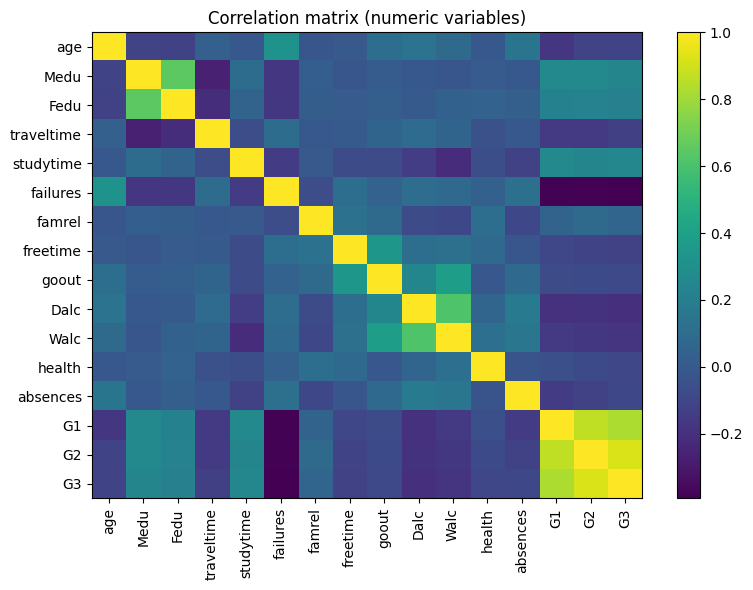

In [12]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr(numeric_only=True)

corr_target = corr["G3"].sort_values(ascending=False)
display(corr_target)

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation matrix (numeric variables)")
plt.colorbar()
plt.tight_layout()
plt.show()


## 5. Visualizations

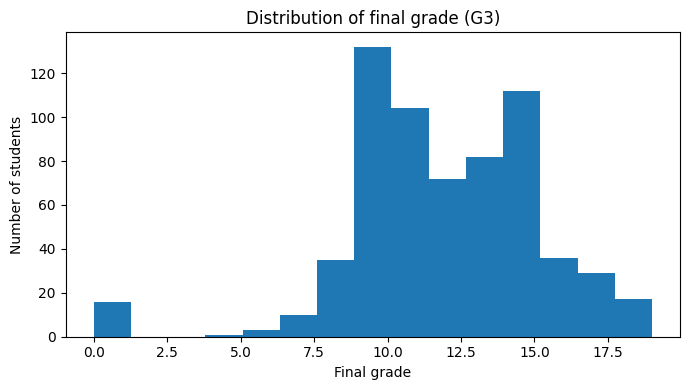

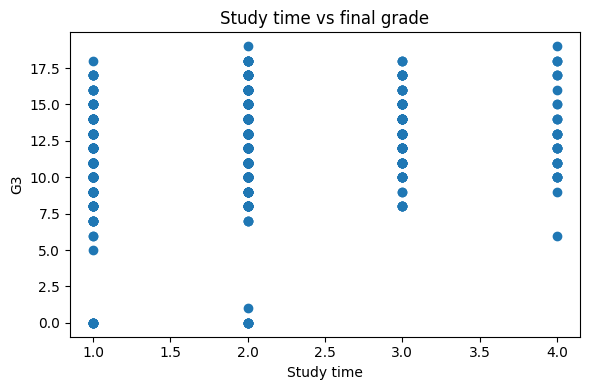

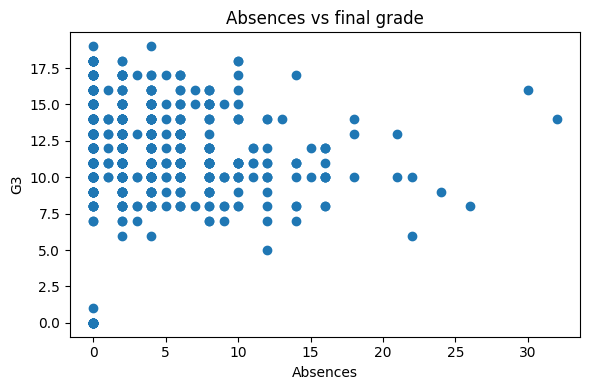

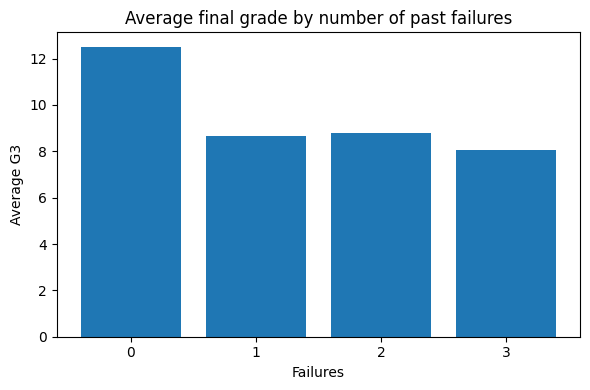

In [13]:
plt.figure(figsize=(7, 4))
plt.hist(df["G3"], bins=15)
plt.title("Distribution of final grade (G3)")
plt.xlabel("Final grade")
plt.ylabel("Number of students")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(df["studytime"], df["G3"])
plt.title("Study time vs final grade")
plt.xlabel("Study time")
plt.ylabel("G3")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(df["absences"], df["G3"])
plt.title("Absences vs final grade")
plt.xlabel("Absences")
plt.ylabel("G3")
plt.tight_layout()
plt.show()

mean_by_failures = df.groupby("failures")["G3"].mean()
plt.figure(figsize=(6, 4))
plt.bar(mean_by_failures.index.astype(str), mean_by_failures.values)
plt.title("Average final grade by number of past failures")
plt.xlabel("Failures")
plt.ylabel("Average G3")
plt.tight_layout()
plt.show()


## 6. Simple interpretation

Typical observations you can comment on in your README or during an interview:
- `G1` and `G2` are usually strongly related to `G3`
- more past `failures` often correspond to lower final grades
- `studytime` can show a positive tendency, even if it is not perfectly linear
- `absences` may negatively affect performance


## 7. Small predictive baseline

This is **not** meant to be a full ML project.  
The goal is only to show that you can:
- prepare features
- separate numeric and categorical columns
- build a preprocessing pipeline
- train a simple regression model
- evaluate the result


In [14]:
target = "G3"
features = [c for c in df.columns if c != target]

X = df[features]
y = df[target]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

print("MAE:", round(mean_absolute_error(y_test, pred), 3))
print("R² :", round(r2_score(y_test, pred), 3))


MAE: 0.765
R² : 0.849
